# Model Evaluation

Evaluate fitted spike models: convergence diagnostics, sparsity analysis,
replicate parameter correlations, global epistasis plots, and mutation
parameter export.

**Outline**
1. Load fitted models and training data
2. Convergence diagnostics
3. Shift sparsity analysis
4. Replicate parameter correlations
5. Global epistasis plots
6. Export mutations DataFrame and intermediate CSVs

In [1]:
import warnings

warnings.filterwarnings("ignore")

import os
import pickle
import sys

sys.path.insert(0, "notebooks")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import multidms.plot
from multidms.model_collection import ModelCollection

from _common import load_config, combine_replicate_muts

In [2]:
config_path = "config/config.yaml"
output_dir = None

In [3]:
# Parameters
config_path = "config/config.yaml"
output_dir = "results-prod-225-spike-data-prep-improvements"


In [4]:
config = load_config(config_path)
spike = config["spike"]
fit_config = spike["fitting"]
lasso_choice = spike["lasso_choice"]
condition_titles = spike["condition_titles"]
condition_colors = spike["condition_colors"]
experiment_conditions = spike["experiment_conditions"]

if output_dir is None:
    output_dir = spike.get("output_dir", "results")

## Load data

In [5]:
with open(os.path.join(output_dir, "fit_collection.pkl"), "rb") as f:
    fit_collection_df = pickle.load(f)

func_score_df = pd.read_csv(
    os.path.join(output_dir, "training_functional_scores.csv")
).fillna({"aa_substitutions": ""})

model_collection = ModelCollection(fit_collection_df)
print(f"Loaded {len(fit_collection_df)} fitted models")
print(f"Loaded {len(func_score_df):,} training variants")

Loaded 14 fitted models
Loaded 303,007 training variants


## Convergence diagnostics

In [6]:
# Build summary table with fitted alpha and beta0 parameters
summary_rows = []
for _, row in model_collection.fit_models.iterrows():
    jm = row.model._jax_model
    r = {
        "dataset": row.dataset_name,
        "fusionreg": row.fusionreg,
        "converged": row.converged,
        "fit_time": row.fit_time,
    }
    # Alpha: shared scalar or per-condition dict
    if hasattr(jm.α, "items"):
        for cond in experiment_conditions:
            title = condition_titles.get(cond, cond)
            r[f"alpha_{title}"] = float(jm.α[cond])
    else:
        r["alpha"] = float(jm.α)
    # Per-condition loss
    for cond in experiment_conditions:
        loss_col = f"{cond}_loss_training"
        if loss_col in model_collection.fit_models.columns:
            r[f"loss_{condition_titles.get(cond, cond)}"] = row[loss_col]
    # Fitted beta0 per condition
    for cond in experiment_conditions:
        title = condition_titles.get(cond, cond)
        r[f"beta0_{title}"] = float(jm.φ[cond].β0)
    summary_rows.append(r)

summary_df = pd.DataFrame(summary_rows)
print(f"{summary_df['converged'].sum()}/{len(summary_df)} models converged\n")
summary_df.round(3)

11/14 models converged



,dataset,fusionreg,converged,fit_time,alpha,loss_Delta,loss_BA.1,loss_BA.2,beta0_Delta,beta0_BA.1,beta0_BA.2
0,rep_1,0.0,False,272,5.537,5760.938,13738.307,12008.644,0.338,0.552,0.237
1,rep_1,0.4,True,168,6.030,6090.164,13839.510,12447.242,0.022,0.328,-0.007
2,rep_1,0.8,True,140,6.124,6576.189,13879.085,12944.956,-0.025,0.284,-0.047
3,rep_1,1.6,True,134,6.011,8111.376,13854.277,14209.962,0.014,0.335,-0.001
4,rep_1,3.2,False,303,4.253,12749.646,13512.037,17292.011,0.694,1.406,1.077
5,rep_1,6.4,True,96,5.879,12681.381,13878.959,18678.807,0.027,0.376,0.054
6,rep_1,12.8,True,215,3.320,15087.932,14345.431,23683.931,1.165,2.465,1.959
7,rep_2,0.0,False,271,5.437,6579.727,9540.099,8978.857,0.333,0.628,0.293
8,rep_2,0.4,True,181,5.942,6979.646,9653.032,9413.130,0.048,0.384,0.028
9,rep_2,0.8,True,156,6.067,7573.696,9682.811,9860.196,-0.008,0.331,-0.023


In [7]:
conv_data = model_collection.convergence_trajectory_df(
    id_vars=("dataset_name", "fusionreg")
)
multidms.plot.convergence_trajectory(
    conv_data,
    id_cols=["dataset_name", "fusionreg"],
    title="Convergence trajectories",
)

alt.LayerChart(...)

## Shift sparsity

Fraction of shift parameters that are exactly zero, across the
regularization grid. Uses the `ModelCollection.shift_sparsity` method
which returns an interactive Altair chart faceted by dataset and
shift parameter.

In [8]:
sparsity_chart, sparsity_data = model_collection.shift_sparsity(return_data=True)
sparsity_chart

cache miss - this could take a moment


alt.FacetChart(...)

## Replicate parameter correlations

Correlation of mutation parameters (beta, shift) between replicates
across the regularization grid. Uses the `ModelCollection.mut_param_dataset_correlation`
method which returns an interactive Altair chart.

In [9]:
corr_chart, corr_data = model_collection.mut_param_dataset_correlation(
    return_data=True
)
corr_chart

alt.FacetChart(...)

## Global epistasis plots

Global epistasis (GE) landscape at the chosen lasso strength, showing
the fitted sigmoid mapping from latent to observed phenotype.

rep_1 (fusionreg=3.2):


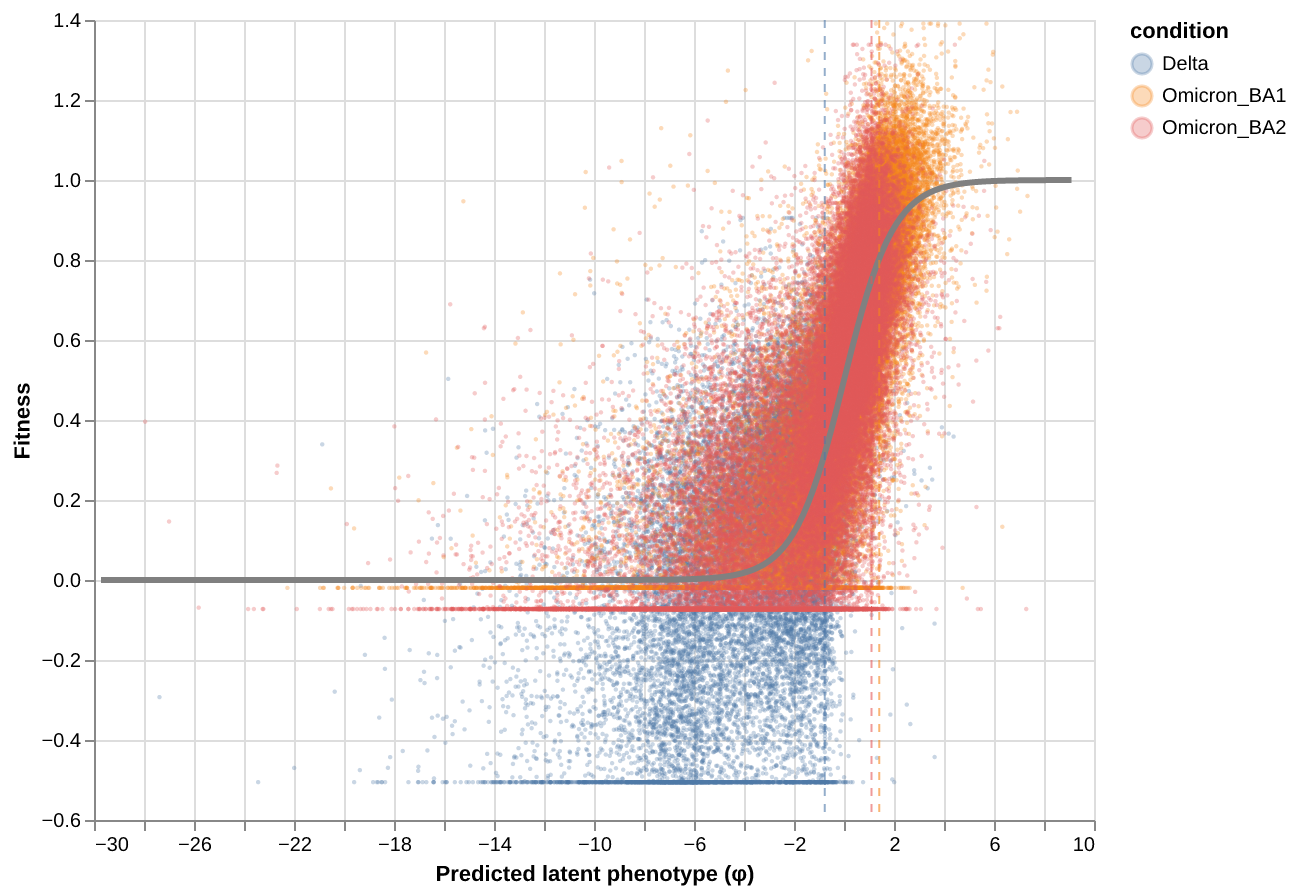

rep_2 (fusionreg=3.2):


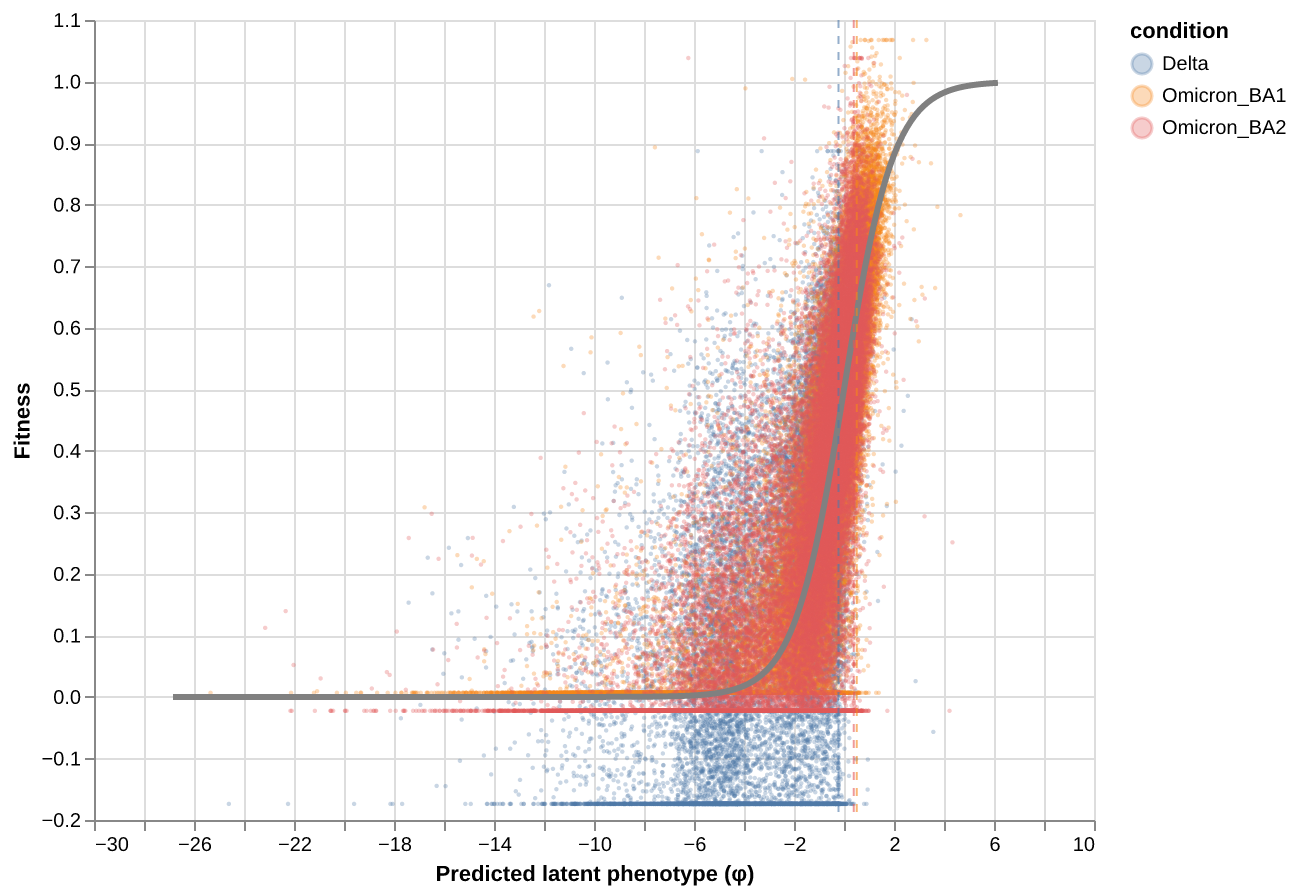

In [10]:
from IPython.display import display, Image
import tempfile

for ds_name in fit_collection_df["dataset_name"].unique():
    representative = (
        model_collection.fit_models
        .query(f"fusionreg == {lasso_choice} and dataset_name == '{ds_name}'")
    )
    if len(representative) == 0:
        print(f"No model at lasso={lasso_choice} for {ds_name}")
        continue
    model = representative.iloc[0].model
    print(f"{ds_name} (fusionreg={lasso_choice}):")
    chart = model.plot_ge_landscape()
    with tempfile.NamedTemporaryFile(suffix=".png") as tmp:
        chart.save(tmp.name, format="png", scale_factor=2)
        display(Image(filename=tmp.name))

## Export mutations DataFrame

Merge mutation parameters from both replicates at the chosen lasso strength.

In [11]:
fit_dict = {}
for _, row in model_collection.fit_models.query(
    f"fusionreg == {lasso_choice}"
).iterrows():
    fit_dict[row.dataset_name] = row.model

mutations_df = combine_replicate_muts(fit_dict)

mutations_df["sense"] = np.where(
    mutations_df["muts"].str.contains("*", regex=False),
    "stop",
    "nonsynonymous",
)

print(f"mutations_df: {len(mutations_df):,} mutations")
print(f"  nonsynonymous: {(mutations_df['sense'] == 'nonsynonymous').sum():,}")
print(f"  stop: {(mutations_df['sense'] == 'stop').sum():,}")
mutations_df.head()

mutations_df: 9,633 mutations
  nonsynonymous: 9,312
  stop: 321


,mutation,wts,sites,muts,rep_1_beta_Delta,rep_2_beta_Delta,avg_beta_Delta,rep_1_beta_Omicron_BA1,rep_2_beta_Omicron_BA1,avg_beta_Omicron_BA1,rep_1_beta_Omicron_BA2,rep_2_beta_Omicron_BA2,avg_beta_Omicron_BA2,rep_1_shift_Delta,rep_2_shift_Delta,avg_shift_Delta,rep_1_shift_Omicron_BA2,rep_2_shift_Omicron_BA2,avg_shift_Omicron_BA2,sense
0,M1F,M,1,F,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,nonsynonymous
1,M1I,M,1,I,-5.349418,-3.530267,-4.439843,-5.349418,-3.530267,-4.439843,-5.349418,-3.530267,-4.439843,0.0,0.000000,0.000000,0.0,0.0,0.0,nonsynonymous
2,M1K,M,1,K,0.000000,-0.961019,-0.480510,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-0.961019,-0.480510,0.0,0.0,0.0,nonsynonymous
3,M1L,M,1,L,0.000000,-0.782271,-0.391136,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-0.782271,-0.391136,0.0,0.0,0.0,nonsynonymous
4,M1T,M,1,T,-4.273816,-3.845033,-4.059424,-4.273816,-3.845033,-4.059424,-4.273816,-3.845033,-4.059424,0.0,0.000000,0.000000,0.0,0.0,0.0,nonsynonymous


## Save outputs

In [12]:
groupby = ("dataset_name", "fusionreg")
collection_muts_df = model_collection.split_apply_combine_muts(
    groupby=groupby
)

mutations_df.to_csv(os.path.join(output_dir, "mutations_df.csv"), index=False)
print(f"Saved mutations_df.csv ({len(mutations_df):,} rows)")

collection_muts_df.to_csv(os.path.join(output_dir, "collection_muts.csv"), index=False)
print(f"Saved collection_muts.csv ({len(collection_muts_df):,} rows)")

sparsity_data.to_csv(os.path.join(output_dir, "fit_sparsity.csv"), index=False)
print(f"Saved fit_sparsity.csv ({len(sparsity_data)} rows)")

corr_data.to_csv(os.path.join(output_dir, "library_replicate_correlation.csv"), index=False)
print(f"Saved library_replicate_correlation.csv ({len(corr_data)} rows)")

Saved mutations_df.csv (9,633 rows)


Saved collection_muts.csv (134,862 rows)
Saved fit_sparsity.csv (56 rows)
Saved library_replicate_correlation.csv (56 rows)
